In [ ]:
!pip install matplotlib

In [1]:
#Visualize data output
import matplotlib.pyplot as plt
import json

In [10]:
fp = open("./qos/crunched_numbers_qos.json")
op = json.load(fp)
op.keys()

dict_keys(['local_ns_same_core_latency', 'local_ns_same_core_throughput', 'local_nice_same_core_latency', 'local_nice_same_core_throughput', 'local_nice_prio_same_core_latency', 'local_nice_prio_same_core_throughput', 'local_ns_diff_core_latency', 'local_ns_diff_core_throughput', 'remote_prio_diff_core_latency', 'remote_prio_diff_core_throughput', 'local_diff_core_latency', 'local_diff_core_throughput', 'remote_same_core_latency', 'remote_same_core_throughput', 'remote_nice_prio_same_core_latency', 'remote_nice_prio_same_core_throughput', 'remote_ns_nice_prio_same_core_latency', 'remote_ns_nice_prio_same_core_throughput', 'remote_nice_same_core_latency', 'remote_nice_same_core_throughput', 'remote_diff_core_latency', 'remote_diff_core_throughput', 'local_ns_nice_same_core_latency', 'local_ns_nice_same_core_throughput', 'remote_stonewall_latency', 'remote_stonewall_throughput', 'remote_ns_stonewall_latency', 'remote_ns_stonewall_throughput', 'remote_ns_nice_same_core_latency', 'remote_n

In [3]:
def plot_lat_percentile(experiment):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v) for k, v in data.items()}
    y = [i for i in data.keys()]
    x = [data[i] for i in y]
    # Plot CDF
    plt.plot(x, y, label=experiment)
    plt.xlabel("Latency ("+u"\u03bc"+"S)")
    plt.ylabel('ECDF')
    plt.legend(loc="lower right")
    plt.grid(True)

def plot_lat_bar(experiment, name, ax, pos):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v)/10**3 for k, v in data.items()}
    boxes = [
        {
            'label' : name,
            'whislo': data[5.00],    # Bottom whisker position
            'q1'    : data[20.0],    # First quartile (25th percentile)
            'med'   : data[50.0],    # Median         (50th percentile)
            'q3'    : data[80.0],    # Third quartile (75th percentile)
            'whishi': data[95.00],    # Top whisker position
            'fliers': []        # Outliers
        }
    ]
    print(boxes)
    ax.bxp(boxes,positions=[pos])
    plt.xlabel("Experiment")
    plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
    plt.grid(True)

def plot_iops_bar(experiment, name):
    y = op[experiment]['iops']['mean']
    y = y / 1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('KIOPS')
    plt.grid(True)

def plot_bw_bar(experiment, name):
    y = op[experiment]['bw']['mean']
    y = y/1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('Bandwidth (MBps)')
    plt.grid(True)


[{'label': 'same core', 'whislo': 31.872, 'q1': 80.384, 'med': 119.296, 'q3': 199.68, 'whishi': 321.536, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 30.848, 'q1': 77.312, 'med': 110.08, 'q3': 183.296, 'whishi': 292.864, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 30.592, 'q1': 76.288, 'med': 105.984, 'q3': 175.104, 'whishi': 276.48, 'fliers': []}]
[{'label': 'different core', 'whislo': 41.216, 'q1': 88.576, 'med': 122.368, 'q3': 193.536, 'whishi': 301.056, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 46.848, 'q1': 95.744, 'med': 127.488, 'q3': 193.536, 'whishi': 296.96, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 28.544, 'q1': 29.568, 'med': 30.592, 'q3': 75.264, 'whishi': 87.552, 'fliers': []}]


Text(0.5, 1.0, 'Latency for local L-Flow')

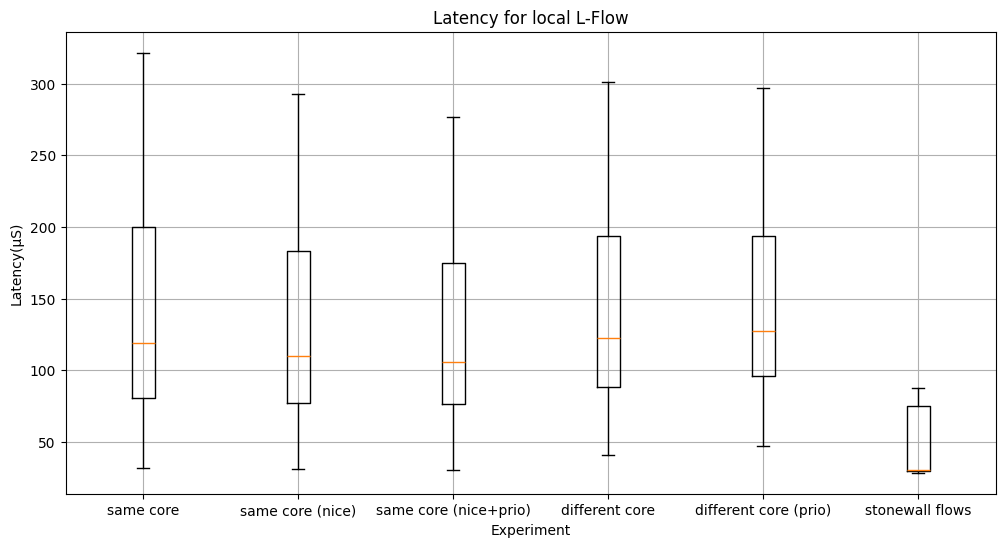

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

plot_lat_bar("local_same_core_latency","same core", ax, 0)
plot_lat_bar("local_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_prio_diff_core_latency","different core (prio)", ax, 4)
plot_lat_bar("local_stonewall_latency", "stonewall flows", ax, 5)
#plt.yscale("log")
plt.title('Latency for local L-Flow')

[{'label': 'same core', 'whislo': 189.44, 'q1': 276.48, 'med': 419.84, 'q3': 708.608, 'whishi': 970.752, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 181.248, 'q1': 268.288, 'med': 399.36, 'q3': 684.032, 'whishi': 921.6, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 187.392, 'q1': 284.672, 'med': 428.032, 'q3': 716.8, 'whishi': 1003.52, 'fliers': []}]
[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

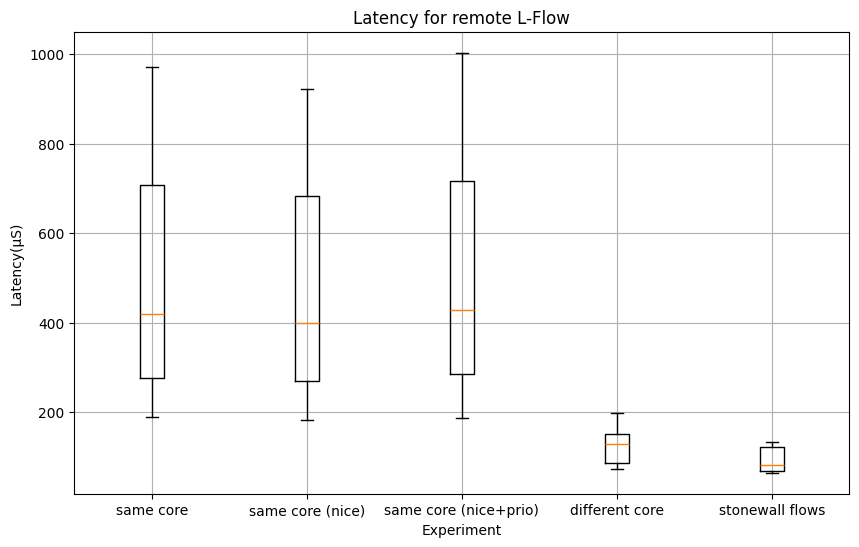

In [12]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

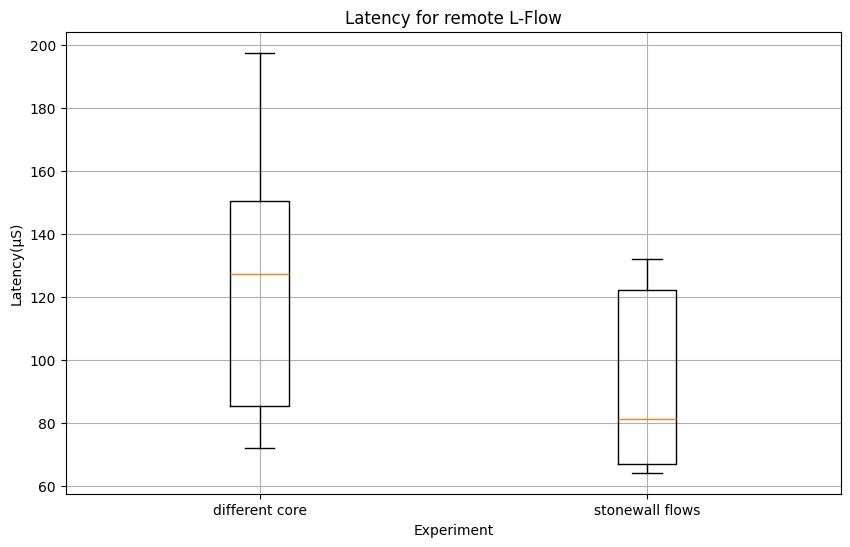

In [13]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for local T-Flow')

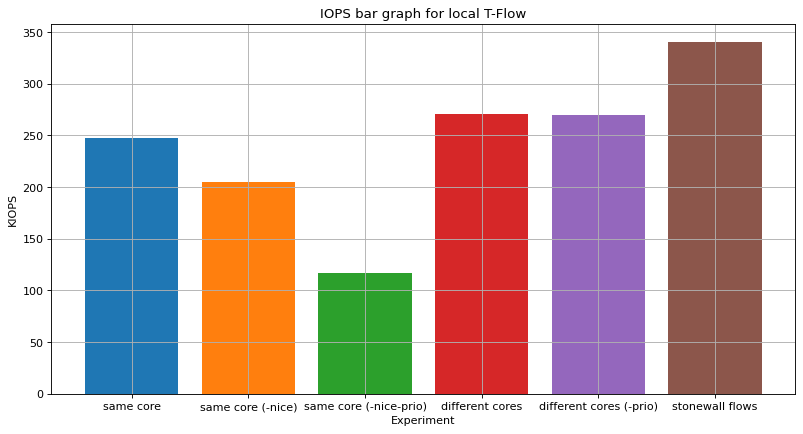

In [6]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("local_same_core_throughput","same core")
plot_iops_bar("local_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("local_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("local_diff_core_throughput","different cores")
plot_iops_bar("local_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("local_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for local T-Flow')


Text(0.5, 1.0, 'IOPS bar graph for remote T-Flow')

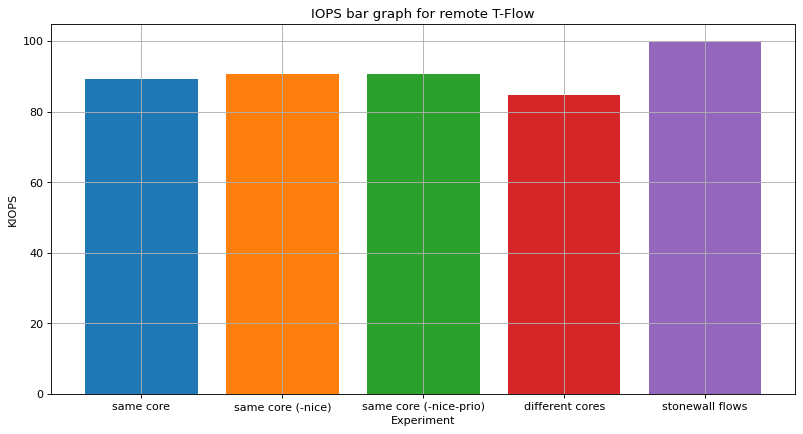

In [7]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("remote_same_core_throughput","same core")
plot_iops_bar("remote_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("remote_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("remote_diff_core_throughput","different cores")
#plot_iops_bar("remote_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("remote_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for remote T-Flow')


[{'label': 'same core', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.936, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'different core', 'whislo': 14.272, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 17.024, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 14.528, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 16.768, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 14.272, 'q1': 15.296, 'med': 15.552, 'q3': 15.936, 'whishi': 16.512, 'fliers': []}]


Text(0.5, 1.0, 'Latency for no shared storage local L-Flow')

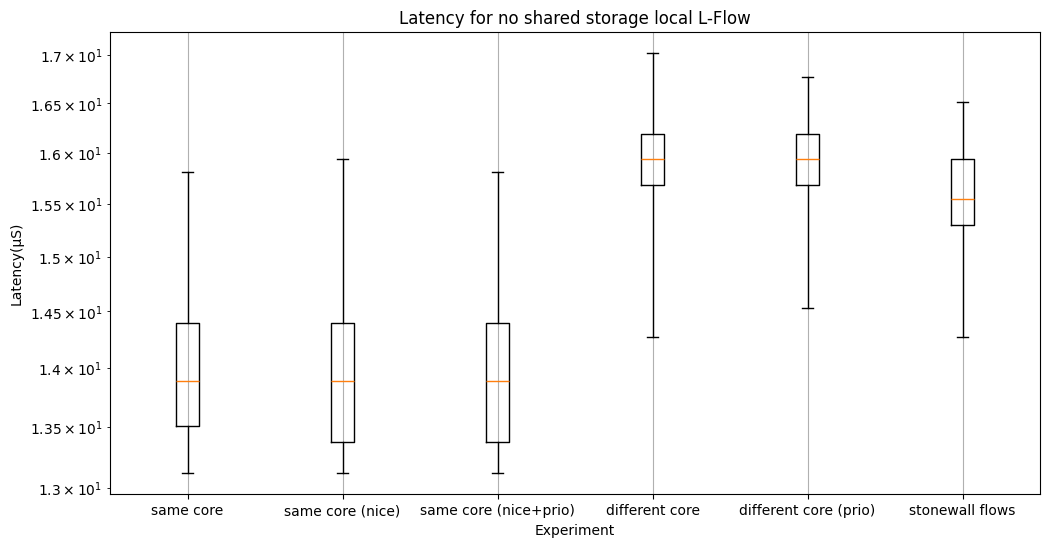

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)


plot_lat_bar("local_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("local_ns_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_ns_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_ns_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_ns_prio_diff_core_latency","different core (prio)", ax, 4)
#plot_lat_bar("local_same_stonewall_latency","stonewall flows (same)", ax, 5)
plot_lat_bar("local_ns_stonewall_latency", "stonewall flows", ax, 5)
plt.yscale("log")
plt.title('Latency for no shared storage local L-Flow')

[{'label': 'same core', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 399.36, 'q1': 651.264, 'med': 749.568, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 387.072, 'q1': 651.264, 'med': 741.376, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'different core', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 48.896, 'q1': 50.944, 'med': 52.48, 'q3': 56.576, 'whishi': 64.768, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

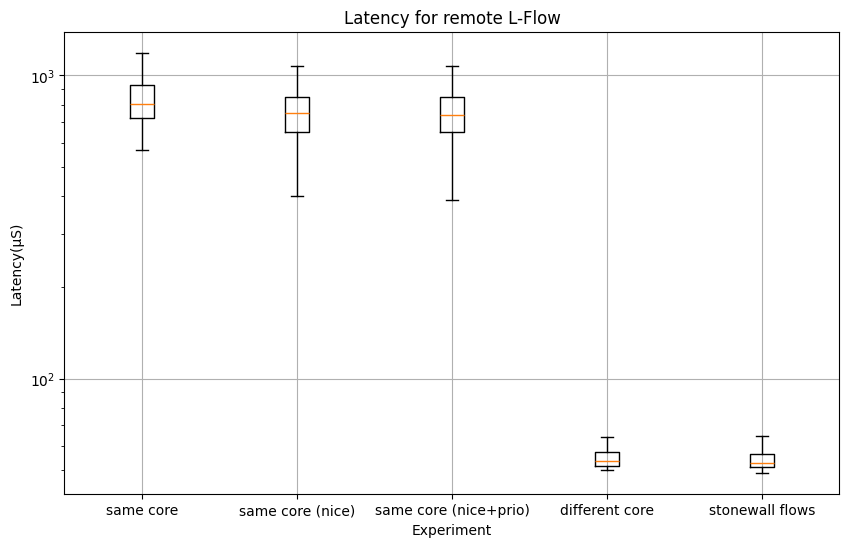

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_ns_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_ns_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_ns_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_ns_stonewall_latency","stonewall flows", ax, 4)
plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'Shared compute only', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'Shared storage and compute', 'whislo': 11.968, 'q1': 12.736, 'med': 14.528, 'q3': 20.096, 'whishi': 62.208, 'fliers': []}]


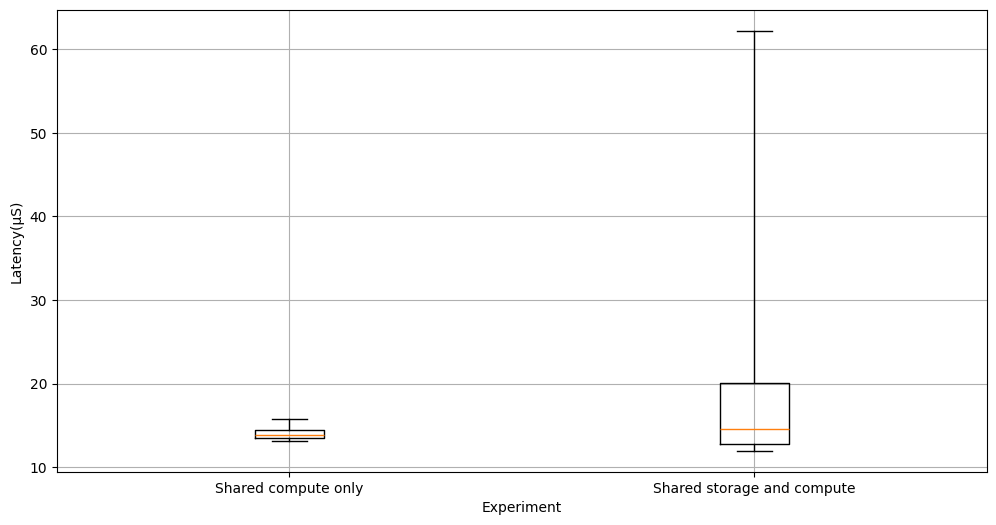

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("local_ns_same_core_latency","Shared compute only", ax, 0)
plot_lat_bar("local_same_core_latency","Shared storage and compute", ax, 1)

[{'label': 'Shared compute and network', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'Shared storage, network and compute', 'whislo': 148.48, 'q1': 280.576, 'med': 602.112, 'q3': 798.72, 'whishi': 1056.768, 'fliers': []}]


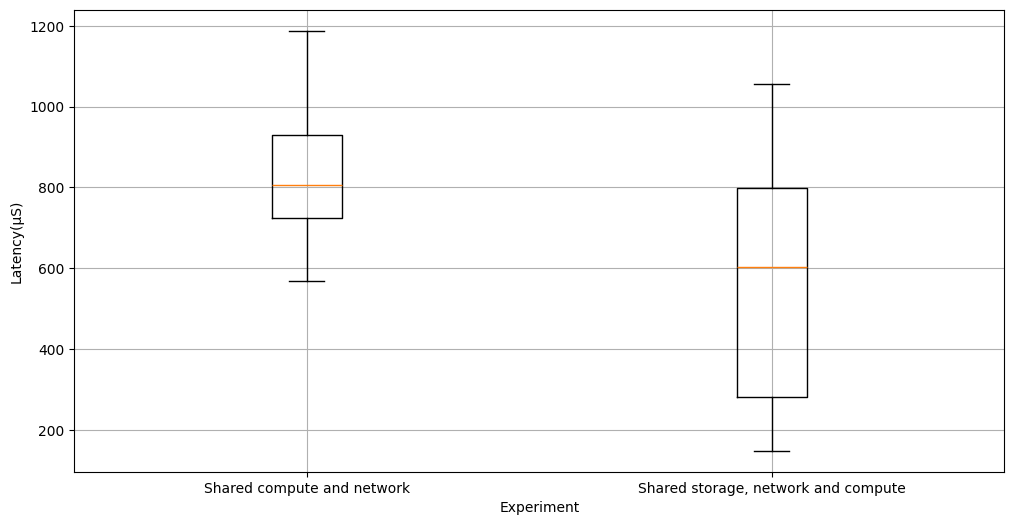

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","Shared compute and network", ax, 0)
plot_lat_bar("remote_same_core_latency","Shared storage, network and compute", ax, 1)

[{'label': 'Shared network only', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'Shared storage and network', 'whislo': 51.968, 'q1': 54.528, 'med': 58.112, 'q3': 65.28, 'whishi': 98.816, 'fliers': []}]


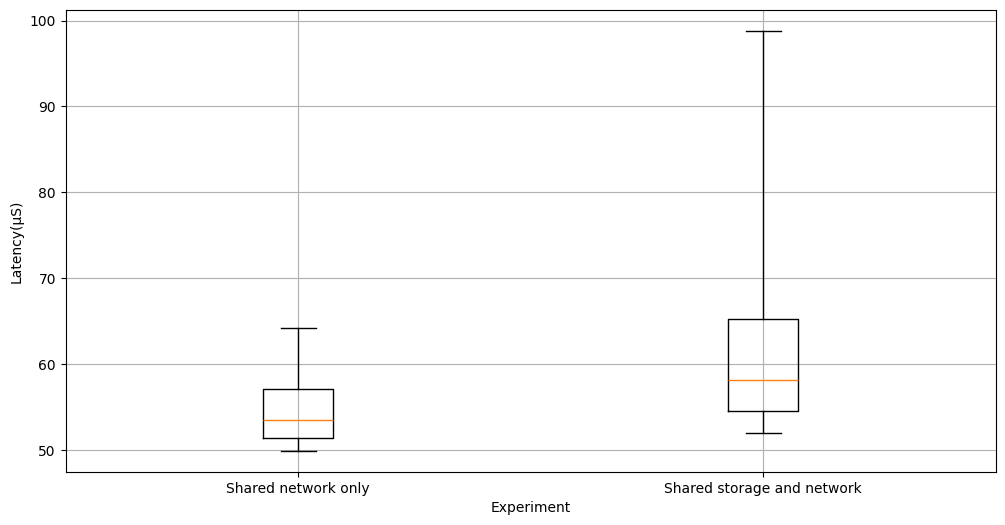

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_diff_core_latency","Shared network only", ax, 0)
plot_lat_bar("remote_diff_core_latency","Shared storage and network", ax, 1)